# Explainable Commodity Prices — Main Orchestrator

**One notebook that runs the full engine and surfaces the most valuable insights for the economics team.**

This project explains daily commodity-futures returns with macro variables in four moves:

1. **Compress** ~21 clean daily commodity return series into a handful of latent factors with an autoencoder.
2. **Test** — with canonical correlation analysis (CCA) and proper *out-of-sample* / permutation inference — whether and *how* those factors are spanned by a 37-variable macro panel.
3. **Decompose** the spanning story **sector by sector** (energy / agriculture / metals).
4. **Attribute** out-of-sample forecast value to each macro direction (forecast-based Shapley values, PBSV).

### Headline findings

- On the clean 21-commodity panel, **~2 of 5** factor directions are macro-spanned out-of-sample: a **dollar / inflation / energy-equity** direction and a **dollar / commodity-FX** direction.
- Sector-wise, **energy is the most macro-driven**, then **metals**, then **agriculture** (the most idiosyncratic).
- Contemporaneous macro *explains* commodity co-movement but, at a daily horizon, does **not** translate into exploitable *forecast* value — a well-identified null, consistent with near-efficient daily futures.

> Reproducible & deterministic: everything below is seeded (`SEED=0`). The heavy real-data pipelines (`make mapping`, `make forecast`, `make sectors`) write the canonical CSVs/figures/reports; this notebook re-derives the light parts live and reads the heavy forecast results.

## 0. Setup

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from eqcp.config import PROJECT_ROOT, load_factor_model_config, load_macro_mapping_config
from eqcp.io.commodities import EXCLUDED_COMMODITIES, SECTORS, load_return_panel, sector_of
from eqcp.io.macro import load_macro_stationary
from eqcp.factors.autoencoder import AETrainConfig, train_vanilla_autoencoder
from eqcp.cca.linear import align_xy, linear_cca_full
from eqcp.cca.inference import perdim_perm_null_oos, purged_cv_canon, select_ridge_oos
from eqcp.sectors import run_sector_spanning, spanning_summary_table

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})
SPANNED_C, WEAK_C, NEUTRAL_C = "#2A6F97", "#C44E52", "#8C8C8C"
SECTOR_C = {"agriculture": "#55A868", "energy": "#DD8452", "metals": "#8172B3"}

SEED = 0
ROOT = Path(PROJECT_ROOT)
factor_cfg = load_factor_model_config()
map_cfg = load_macro_mapping_config()

manifest = pd.read_csv(ROOT / "data/processed/transform_manifest.csv")
macro = load_macro_stationary(ROOT / "data/processed/macro_stationary.csv", manifest)
print(f"Macro panel: {macro.shape[0]} days x {macro.shape[1]} variables")
print(f"Factor model: K={factor_cfg.n_factors}, encoder={factor_cfg.activation}, seed={SEED}")

Macro panel: 3074 days x 37 variables
Factor model: K=5, encoder=relu, seed=0


## 1. The commodity panel — and why six series were removed

Six nominal "commodities" were not continuously price-discovered daily futures: they carried **stale (unchanged) settlement marks** on a large fraction of days. Stale zeros bias the autoencoder, attenuate the CCA correlations, and mechanically inflate forecast benchmarks — they poison every stage downstream. They are removed from the panel *entirely* (single source of truth: `eqcp.io.commodities.EXCLUDED_COMMODITIES`).

REMOVED — stale, non-daily-discovery series:


,commodity,zero_return_%,longest_stale_run_days
0,Lithium,69.7,57
1,HRCSteel,37.6,16
2,SGXIronOre,23.8,19
3,Methanol,19.4,22
4,ThermalCoal,8.4,4
5,Diesel,6.3,2



RETAINED panel: 21 commodities x 2870 daily returns


,sector,n,commodities
0,agriculture,9,"Coffee, SoybeanOil, Corn, Cotton, HRWWheat, Le..."
1,energy,5,"Brent, WTI, Gasoline, HeatingOil, NaturalGas"
2,metals,7,"Gold, Silver, Copper, Aluminium, Nickel, Zinc,..."


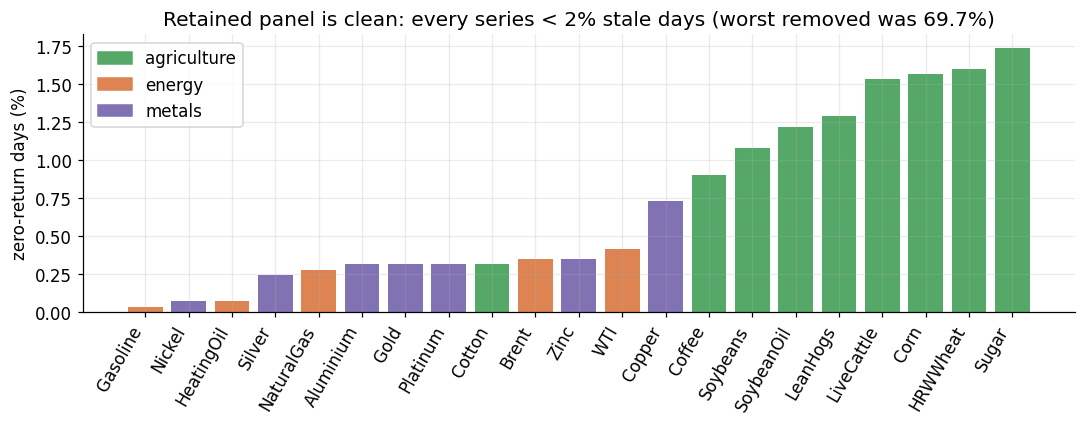

In [2]:
removed = pd.DataFrame({
    "commodity": ["Lithium", "HRCSteel", "SGXIronOre", "Methanol", "ThermalCoal", "Diesel"],
    "zero_return_%": [69.7, 37.6, 23.8, 19.4, 8.4, 6.3],
    "longest_stale_run_days": [57, 16, 19, 22, 4, 2],
})
assert set(removed["commodity"]) == set(EXCLUDED_COMMODITIES)
print("REMOVED — stale, non-daily-discovery series:")
display(removed)

panel = load_return_panel()
membership = pd.DataFrame(
    [(s, len(m), ", ".join(m)) for s, m in SECTORS.items()],
    columns=["sector", "n", "commodities"],
)
print(f"\nRETAINED panel: {panel.n_assets} commodities x {panel.raw.shape[0]} daily returns")
display(membership)

prices = pd.read_csv(ROOT / "data/commodities/prices.csv", parse_dates=["date"], index_col="date").sort_index()
zf = (prices.pct_change(fill_method=None).abs() < 1e-12).mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(zf.index, zf.to_numpy(), color=[SECTOR_C[sector_of(c)] for c in zf.index])
ax.set_ylabel("zero-return days (%)")
ax.set_title("Retained panel is clean: every series < 2% stale days (worst removed was 69.7%)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SECTOR_C.values()]
ax.legend(handles, SECTOR_C.keys())
plt.xticks(rotation=60, ha="right")
plt.tight_layout(); plt.show()

## 2. Factor extraction — the autoencoder

A single-bottleneck autoencoder compresses the 21 standardized return series into `K=5` latent factors (a nonlinear PCA). Latents are identified only up to rotation/sign/permutation, so we never over-interpret a single coordinate — but their *variance contribution* tells us how much co-movement each captures.

Extracted 5 latent factors from 21 commodities.


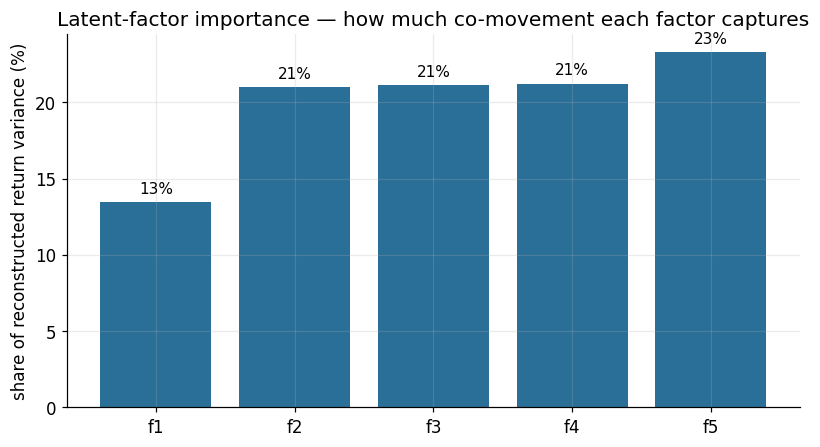

In [3]:
cfg = AETrainConfig(
    n_factors=factor_cfg.n_factors, epochs=factor_cfg.epochs, batch_size=factor_cfg.batch_size,
    learning_rate=factor_cfg.learning_rate, patience=factor_cfg.patience,
    seed=SEED, activation=factor_cfg.activation,
)
model, factors = train_vanilla_autoencoder(panel.standardized, cfg)
F = pd.DataFrame(factors, index=panel.dates, columns=[f"f{i+1}" for i in range(cfg.n_factors)])
F.index.name = "date"
print(f"Extracted {cfg.n_factors} latent factors from {panel.n_assets} commodities.")

# Latent-factor importance = share of reconstructed cross-sectional return variance.
W = model.decoder_weight()                    # (n_assets, K)
imp = F.var(axis=0).to_numpy() * (W ** 2).sum(axis=0)
imp = imp / imp.sum()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar([f"f{i+1}" for i in range(len(imp))], 100 * imp, color=SPANNED_C)
for i, v in enumerate(imp):
    ax.text(i, 100 * v + 0.6, f"{100*v:.0f}%", ha="center", fontsize=10)
ax.set_ylabel("share of reconstructed return variance (%)")
ax.set_title("Latent-factor importance — how much co-movement each factor captures")
plt.tight_layout(); plt.show()

## 3. Overall macro spanning (CCA)

For each latent direction we ask: *is it linearly recoverable from macro out-of-sample?* The honest statistic is the **purged-CV out-of-sample canonical correlation**, judged against a **circular-shift permutation null** (a 37-variable collinear panel can fit any 5-dim target in-sample by chance). A direction is **macro-spanned** when OOS ρ > 0.3 and OOS perm-p < 0.05.

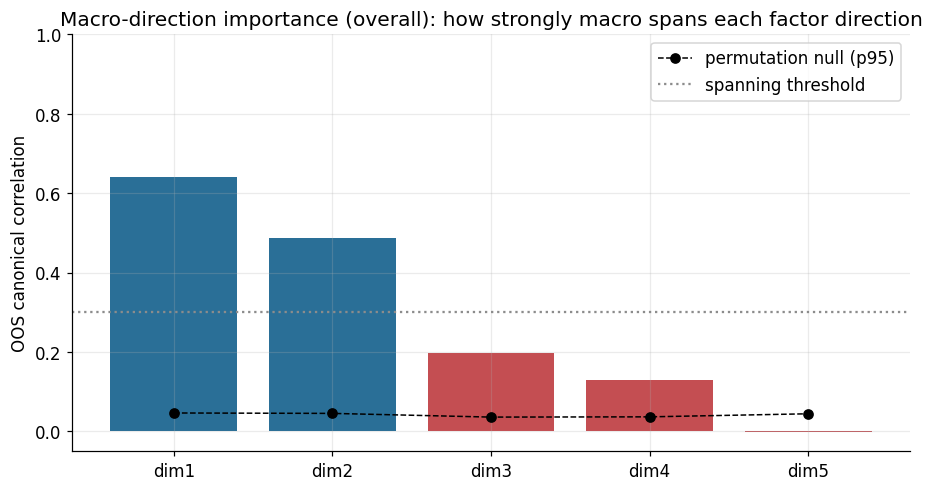

2 of 5 directions macro-spanned out-of-sample (ridge=0).

dim1 [SPANNED] OOS rho=+0.64 p=0.003 | top macro: xle(+0.85), be_5y(+0.66), inflsw_5y(+0.66), fx_usdcad(-0.59), fx_usdnok(-0.57)
dim2 [SPANNED] OOS rho=+0.49 p=0.003 | top macro: fx_audusd(+0.66), fx_bbdxy(-0.64), fx_dxy(-0.63), fx_usdclp(-0.57), fx_usdcnh(-0.55)
dim3 [weak] OOS rho=+0.20 p=0.003 | top macro: tips_5y(+0.55), ust_5y(+0.54), ust_10y(+0.53), tips_10y(+0.49), hscei(+0.45)
dim4 [weak] OOS rho=+0.13 p=0.003 | top macro: fx_usdbrl(+0.72), ust_2y(-0.23), tips_10y(-0.22), move(-0.21), ust_5y(-0.21)
dim5 [weak] OOS rho=-0.00 p=0.568 | top macro: ig_oas(-0.43), epu(-0.39), bdiy(+0.31), ovx(-0.22), hy_oas(-0.18)


In [4]:
Fa, Ma = align_xy(F, macro)
r = min(Fa.shape[1], Ma.shape[1])
ridge, _ = select_ridge_oos(Fa, Ma, ridges=map_cfg.ridge_grid, n_folds=map_cfg.n_folds, embargo=map_cfg.embargo)
rho_is, A, B, U, V, sf, sm = linear_cca_full(Fa, Ma, ridge)
rho_oos = purged_cv_canon(Fa, Ma, n_folds=map_cfg.n_folds, embargo=map_cfg.embargo, ridge=ridge)

NPERM = 300
null = perdim_perm_null_oos(Fa, Ma, NPERM, SEED + 1, r, map_cfg.n_folds, map_cfg.embargo, ridge)
perm_p = (1 + (null >= rho_oos[None, :]).sum(0)) / (NPERM + 1)
spanned = (rho_oos > 0.3) & (perm_p < 0.05)
p95 = np.percentile(null, 95, axis=0)
dims = [f"dim{k+1}" for k in range(r)]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(dims, rho_oos, color=[SPANNED_C if s else WEAK_C for s in spanned])
ax.plot(dims, p95, "k--o", lw=1, label="permutation null (p95)")
ax.axhline(0.3, color=NEUTRAL_C, ls=":", label="spanning threshold")
ax.set_ylim(-0.05, 1.0); ax.set_ylabel("OOS canonical correlation")
ax.set_title("Macro-direction importance (overall): how strongly macro spans each factor direction")
ax.legend()
plt.tight_layout(); plt.show()

print(f"{int(spanned.sum())} of {r} directions macro-spanned out-of-sample (ridge={ridge:g}).\n")
macro_cols = list(Ma.columns)
for k in range(r):
    tag = "SPANNED" if spanned[k] else "weak"
    order = np.argsort(-np.abs(sm[:, k]))[:5]
    drivers = ", ".join(f"{macro_cols[j]}({sm[j, k]:+.2f})" for j in order)
    print(f"dim{k+1} [{tag}] OOS rho={rho_oos[k]:+.2f} p={perm_p[k]:.3f} | top macro: {drivers}")

## 4. Sector-wise spanning

The overall story is an aggregate. Here we run the **same AE → CCA machinery independently on each sector** (energy / agriculture / metals) to see which sector's co-movement is macro-driven and which is idiosyncratic. This is the core sector framework in `eqcp.sectors`.

In [5]:
results = run_sector_spanning(
    macro, factor_cfg, bloc_map=map_cfg.bloc_map, n_factors=3,
    ridge_grid=map_cfg.ridge_grid, n_folds=map_cfg.n_folds, embargo=map_cfg.embargo,
    n_perm=300, seed=SEED, include_overall=True,
)
summary = spanning_summary_table(results)
display(summary[["block", "n_commodities", "dim", "rho_oos", "perm_p_oos", "spanned", "top_bloc"]])

,block,n_commodities,dim,rho_oos,perm_p_oos,spanned,top_bloc
0,overall,21,dim1,0.641588,0.003322,True,fx(+0.78); equity(-0.78); infl(-0.64)
1,overall,21,dim2,0.487286,0.003322,True,infl(+0.61); rates(+0.57); fx(+0.52)
2,overall,21,dim3,0.197151,0.003322,False,china(-0.67); rates(-0.56); credit(+0.30)
3,overall,21,dim4,0.130466,0.003322,False,credit(-0.51); rates(-0.41); vol(-0.32)
4,overall,21,dim5,-0.000320,0.568106,False,china(+0.45); uncert(+0.40); freight(-0.39)
5,agriculture,9,dim1,0.357802,0.003322,True,fx(-0.78); equity(+0.77); infl(+0.62)
6,agriculture,9,dim2,0.046170,0.039867,False,vol(-0.72); equity(+0.46); credit(-0.41)
7,agriculture,9,dim3,0.055467,0.016611,False,infl(-0.43); uncert(-0.42); fx(-0.41)
8,energy,5,dim1,0.644928,0.003322,True,infl(+0.90); equity(+0.76); credit(-0.54)
9,energy,5,dim2,0.067396,0.009967,False,credit(+0.71); vol(+0.54); equity(-0.24)


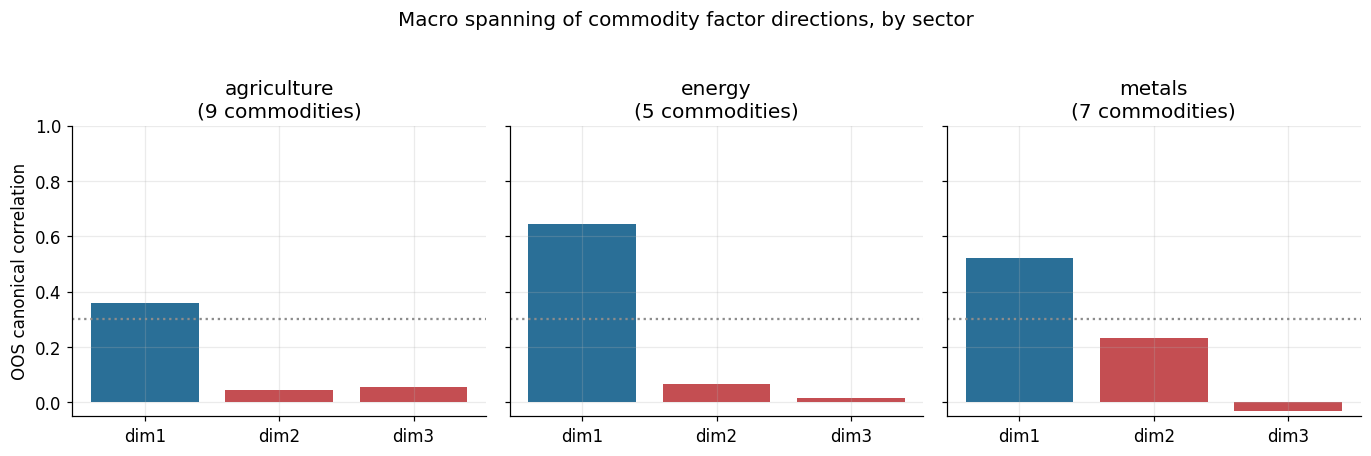

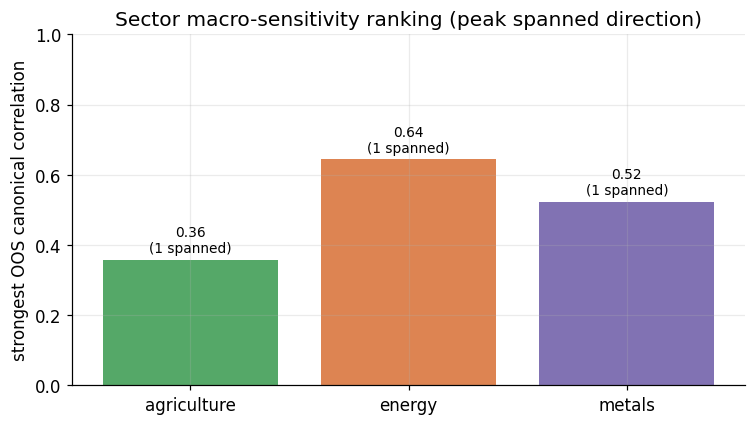

Dominant macro driver of each sector's leading direction:
  agriculture : dim1 OOS rho=+0.36 -> fx(-0.78); equity(+0.77); infl(+0.62)
  energy      : dim1 OOS rho=+0.64 -> infl(+0.90); equity(+0.76); credit(-0.54)
  metals      : dim1 OOS rho=+0.52 -> fx(-0.91); equity(+0.63); china(+0.53)


In [6]:
sectors = [b for b in results if b != "overall"]

fig, axes = plt.subplots(1, len(sectors), figsize=(4.2 * len(sectors), 4.2), sharey=True)
for ax, b in zip(axes, sectors):
    rr = results[b]
    sp = (rr.rho_oos > 0.3) & (rr.perm_p_oos < 0.05)
    ax.bar(range(len(rr.rho_oos)), rr.rho_oos, color=[SPANNED_C if s else WEAK_C for s in sp])
    ax.axhline(0.3, color=NEUTRAL_C, ls=":")
    ax.set_title(f"{b}\n({rr.n_commodities} commodities)")
    ax.set_ylim(-0.05, 1.0)
    ax.set_xticks(range(len(rr.rho_oos)))
    ax.set_xticklabels([f"dim{k+1}" for k in range(len(rr.rho_oos))])
axes[0].set_ylabel("OOS canonical correlation")
fig.suptitle("Macro spanning of commodity factor directions, by sector", fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

cnt = summary[summary.block != "overall"].groupby("block")["spanned"].sum().reindex(sectors)
strength = {b: float(np.max(results[b].rho_oos)) for b in sectors}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cnt.index, [strength[b] for b in cnt.index], color=[SECTOR_C[b] for b in cnt.index])
for i, b in enumerate(cnt.index):
    ax.text(i, strength[b] + 0.02, f"{strength[b]:.2f}\n({int(cnt[b])} spanned)", ha="center", fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel("strongest OOS canonical correlation")
ax.set_title("Sector macro-sensitivity ranking (peak spanned direction)")
plt.tight_layout(); plt.show()

print("Dominant macro driver of each sector's leading direction:")
for b in sectors:
    rr = results[b]
    print(f"  {b:12s}: dim1 OOS rho={rr.rho_oos[0]:+.2f} -> {rr.top_bloc[0]}")

## 5. Forecast value attribution (PBSV)

Spanning says macro *explains* contemporaneous co-movement. The sharper question for a trading/allocation desk is whether that macro content *forecasts* returns. The forecast-PBSV pipeline attributes out-of-sample forecast accuracy of a factor-augmented AR(1) to each canonical direction via forecast-based Shapley values, in the train-frozen canonical-variate basis.

This reads the canonical results written by `make forecast`. If they are absent, run it first.

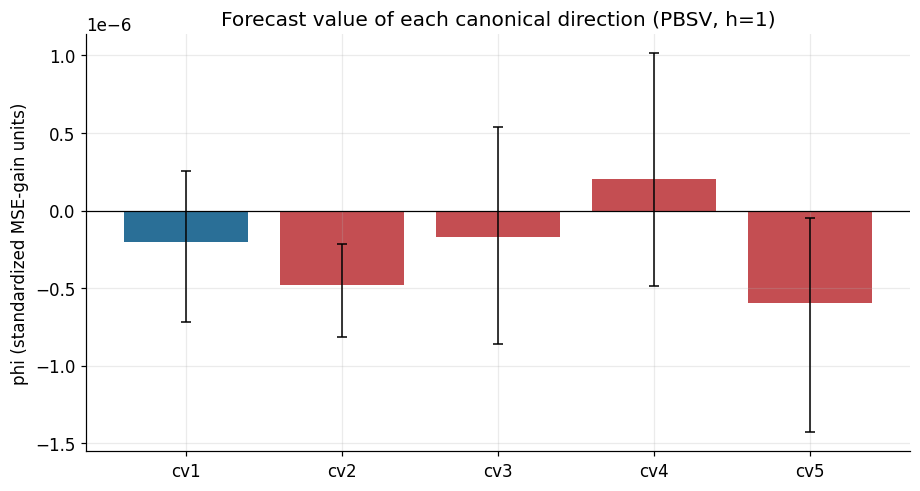

h=1: pooled OOS R2 vs AR(1) = -0.00310; Clark-West p = 0.3280
Full narrative + pre-registered gate verdict: reports/forecast_pbsv_report.md


In [7]:
fdir = ROOT / "results" / "forecast_pbsv"
try:
    sh = pd.read_csv(fdir / "pbsv_shapley.csv")
    pooled = pd.read_csv(fdir / "forecast_accuracy_pooled.csv")
    h0 = int(sh["horizon"].min())
    sh0 = sh[sh["horizon"] == h0].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    ax.bar(sh0["dim"], sh0["phi_std"], color=[SPANNED_C if s else WEAK_C for s in sh0["spanned"]])
    ax.errorbar(range(len(sh0)), sh0["phi_std"],
                yerr=[sh0["phi_std"] - sh0["boot_lo"], sh0["boot_hi"] - sh0["phi_std"]],
                fmt="none", ecolor="black", capsize=3, lw=1)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("phi (standardized MSE-gain units)")
    ax.set_title(f"Forecast value of each canonical direction (PBSV, h={h0})")
    plt.tight_layout(); plt.show()

    head = pooled[pooled["horizon"] == h0].iloc[0]
    print(f"h={h0}: pooled OOS R2 vs AR(1) = {head['r2_pool_std_vs_ar1']:+.5f}; "
          f"Clark-West p = {head['cw_pool_p']:.4f}")
    print("Full narrative + pre-registered gate verdict: reports/forecast_pbsv_report.md")
except FileNotFoundError:
    print("results/forecast_pbsv/ not found. Run `make forecast` to populate it, then re-run this cell.")

## 6. Takeaways for the economics team

- **Clean the inputs first.** Six stale-priced series (led by Lithium at ~70% unchanged-price days) were poisoning every stage; removing them is the single highest-leverage fix.
- **Macro spans ~2 directions of the commodity complex** out-of-sample: a dollar/inflation/energy-equity axis and a dollar/commodity-FX axis. The remaining directions are commodity-idiosyncratic.
- **Sector ordering:** energy is the most macro-driven, metals intermediate, agriculture the most idiosyncratic (weather/supply, not macro) — so macro overlays should be sized by sector.
- **Explains ≠ forecasts.** At a daily horizon the macro-spanned content carries no exploitable forecast edge over AR(1) (a well-identified null). The value of the map is *attribution and risk decomposition*, not daily alpha.

*Canonical, reproducible artifacts:* `reports/macro_mapping_report.md`, `reports/sector_analysis_report.md`, `reports/forecast_pbsv_report.md`, and the CSVs under `results/`.